In [48]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42	
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = '/home/wychen/workspace/vllm/examples/logs/1gpu_bs512_prompts300'
BASELINE_DATA_PATH = '/home/wychen/workspace/vllm-org/vllm/examples/logs/1gpu'
linestyles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '*', 'p', 'h']
hatches = ['////', '\\\\\\', '||||', '----', '++++', 'xx', 'oo', 'OO', '.', '**']

In [49]:
def get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers, baseline_policy):
    output_tokens, reqs, mean_tpot, p99_tpot,  mean_ttft, p99_ttft, mean_itl, p99_itl = [], [], [], [], [], [], [], []
    for store_cache_layer in store_cache_layers:
        if baseline_policy == 'full_mem':
            filename = f'{DATA_PATH}/test_{model_name}_client_0.9_{req_rate}_{total_reqs}_swap_{store_cache_layer}.log'
        else:    
            filename = f'{DATA_PATH}/test_{model_name}_client_{gpu_utilization}_{req_rate}_{total_reqs}_swap_{store_cache_layer}.log'
        with open(filename, 'r') as f:
            lines = f.readlines()
            output_tokens_tgt, reqs_tgt, mean_tpot_, p99_tpot_, mean_ttft_, p99_ttft_, mean_itl_, p99_itl_ = [], [], [], [], [], [], [], []
            for line in lines:
                if 'Output token throughput' in line:
                    output_tokens_tgt.append(float(line.split()[-1]))
                if 'Request throughput' in line:
                    reqs_tgt.append(float(line.split()[-1]))
                if 'Mean TPOT' in line:
                    mean_tpot_.append(float(line.split()[-1]))
                if 'P99 TPOT' in line:
                    p99_tpot_.append(float(line.split()[-1]))
                if 'Mean TTFT' in line:
                    mean_ttft_.append(float(line.split()[-1]))
                if 'P99 TTFT' in line:
                    p99_ttft_.append(float(line.split()[-1]))    
                if 'Mean ITL' in line:
                    mean_itl_.append(float(line.split()[-1]))
                if 'P99 ITL' in line:
                    p99_itl_.append(float(line.split()[-1]))    

        output_tokens.append(np.mean(output_tokens_tgt))
        reqs.append(np.mean(reqs_tgt))
        mean_tpot.append(np.mean(mean_tpot_))
        p99_tpot.append(np.mean(p99_tpot_))
        mean_ttft.append(np.mean(mean_ttft_))
        p99_ttft.append(np.mean(p99_ttft_))
        mean_itl.append(np.mean(mean_itl_))
        p99_itl.append(np.mean(p99_itl_))

    return output_tokens, reqs, mean_tpot, p99_tpot, mean_ttft, p99_ttft, mean_itl, p99_itl 

In [50]:
def get_baseline_res(model_name, gpu_utilization, req_rate, total_reqs, baseline_policy):
    if baseline_policy == 'full_mem':
        filename = f'{BASELINE_DATA_PATH}/{model_name}_client_0.9_{req_rate}_{total_reqs}_swap_1.0_1gpu.log'
        filename = f'{DATA_PATH}/test_{model_name}_client_0.9_{req_rate}_{total_reqs}_swap_1.0.log'
    else:    
        filename = f'{BASELINE_DATA_PATH}/{model_name}_client_{gpu_utilization}_{req_rate}_{total_reqs}_{baseline_policy}_1.0_1gpu.log'

    with open(filename, 'r') as f:
        lines = f.readlines()
        output_tokens_tgt, reqs_tgt, mean_tpot_, p99_tpot_, mean_ttft, p99_ttft, mean_itl, p99_itl = [], [], [], [], [], [], [], []
        for line in lines:
            if 'Output token throughput' in line:
                output_tokens_tgt.append(float(line.split()[-1]))
            if 'Request throughput' in line:
                reqs_tgt.append(float(line.split()[-1]))
            if 'Mean TPOT' in line:
                mean_tpot_.append(float(line.split()[-1]))
            if 'P99 TPOT' in line:
                p99_tpot_.append(float(line.split()[-1]))
            if 'Mean TTFT' in line:
                mean_ttft.append(float(line.split()[-1]))  
            if 'P99 TTFT' in line:
                p99_ttft.append(float(line.split()[-1]))      
            if 'Mean ITL' in line:
                mean_itl.append(float(line.split()[-1]))
            if 'P99 ITL' in line:
                p99_itl.append(float(line.split()[-1]))        
        
    return np.mean(output_tokens_tgt), np.mean(reqs_tgt), np.mean(mean_tpot_), np.mean(p99_tpot_), np.mean(mean_ttft), np.mean(p99_ttft), np.mean(mean_itl), np.mean(p99_itl)         

In [51]:
# plot throughput
def plot_throughput(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers, baseline_policy):
    output_tokens, reqs, mean_tpot, p99_tpot, mean_ttft, p99_ttft, mean_itl, p99_itl = get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers, baseline_policy)
    baseline_output_tokens, baseline_reqs, baseline_mean_tpot, baseline_p99_tpot, baseline_mean_ttft, baseline_p99_ttft, baseline_mean_itl, baseline_p99_itl = get_baseline_res(model_name, gpu_utilization, req_rate, total_reqs, baseline_policy)
    # 计算增长百分比
    output_tokens_imp = [(output_tokens[i]-baseline_output_tokens) / baseline_output_tokens * 100 for i in range(len(output_tokens))]
    reqs_imp = [(reqs[i]-baseline_reqs) / baseline_reqs * 100 for i in range(len(reqs))]
    mean_tpot_imp = [(baseline_mean_tpot-mean_tpot[i]) / baseline_mean_tpot *100 for i in range(len(mean_tpot))]
    p99_tpot_imp = [(baseline_p99_tpot-p99_tpot[i]) / baseline_p99_tpot *100 for i in range(len(p99_tpot))]
    mean_ttft_imp = [(baseline_mean_ttft-mean_ttft[i]) / baseline_mean_ttft *100 for i in range(len(mean_ttft))]
    p99_ttft_imp = [(baseline_p99_ttft-p99_ttft[i]) / baseline_p99_ttft *100 for i in range(len(p99_ttft))]
    mean_itl_imp = [(baseline_mean_itl-mean_itl[i]) / baseline_mean_itl *100 for i in range(len(mean_itl))]
    p99_itl_imp = [(baseline_p99_itl-p99_itl[i]) / baseline_p99_itl *100 for i in range(len(p99_itl))]

    return output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp
    

In [52]:
# 绘制一张大图，将不同req_rate的结果放在一张图上, 6个指标, 这张大图包含6个子图，legend放在右上角
def plot_big_fig(baseline_policy, req_rates, store_cache_layers, mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_ttft_imps, mean_p99_ttft_imps, mean_mean_itl_imps, mean_p99_itl_imps):
    print(f'mean_output_tokens_imps: {mean_output_tokens_imps}')
    fig = plt.figure(figsize=(18, 2.5), dpi=120)
    axes = [fig.add_subplot(1, 6, i+1) for i in range(6)]
    for i, ax in enumerate(axes):
        ax.plot(store_cache_layers, mean_output_tokens_imps[i], label='out_toks', linestyle=linestyles[0], marker=markers[0], color=plt.cm.Dark2(0/6), markersize=5)
        ax.plot(store_cache_layers, mean_reqs_imps[i], label='reqs', linestyle=linestyles[1], marker=markers[1], color=plt.cm.Dark2(1/6), markersize=5)
        # ax.plot(store_cache_layers, mean_mean_tpot_imps[i], label='avg_tpot', linestyle=linestyles[2], marker=markers[2], color=plt.cm.Dark2(2/6), markersize=5)
        ax.plot(store_cache_layers, mean_p99_tpot_imps[i], label='p99_tpot', linestyle=linestyles[3], marker=markers[3], color=plt.cm.Dark2(3/6), markersize=5)
        # ax.plot(store_cache_layers, mean_mean_ttft_imps[i], label='avg_ttft', linestyle=linestyles[0], marker=markers[4], color=plt.cm.Dark2(4/6), markersize=5)
        ax.plot(store_cache_layers, mean_p99_ttft_imps[i], label='p99_ttft', linestyle=linestyles[1], marker=markers[5], color=plt.cm.Dark2(5/6), markersize=5)
        # ax.plot(store_cache_layers, mean_mean_itl_imps[i], label='avg_itl', linestyle=linestyles[2], marker=markers[6], color=plt.cm.Dark2(6/6), markersize=5)
        ax.plot(store_cache_layers, mean_p99_itl_imps[i], label='p99_itl', linestyle=linestyles[3], marker=markers[7], color=plt.cm.Dark2(7/6), markersize=5)
        ax.set_xlabel('Cache layers(%)')
        if i == 0 : ax.set_ylabel('Improvement(%)')
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.grid(linestyle='-.', alpha=0.3)
        # 除了第一个子图，其他子图的y轴不显示
        # if i != 0: ax.set_yticklabels([])
        # ax.set_ylim(min(min(mean_output_tokens_imps[i]), min(mean_reqs_imps[i]), min(mean_mean_tpot_imps[i]), min(mean_p99_tpot_imps[i]), min(mean_mean_itl_imps[i]), min(mean_p99_itl_imps[i]))*0.8, max(max(mean_output_tokens_imps[i]), max(mean_reqs_imps[i]), max(mean_mean_tpot_imps[i]), max(mean_p99_tpot_imps[i]), max(mean_mean_itl_imps[i]), max(mean_p99_itl_imps[i]))*1.4)
        # ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))
        # ax.yaxis.set_major_locator(plt.MultipleLocator(20))
        # ax.set_ylim(-10, 80)
        # x轴标签显示数字乘以100
        ax.set_xticklabels([f'{int(x*100)}' for x in ax.get_xticks()])
        ax.set_title(f'{req_rates[i]} reqs/s')
    # legend 放在右上角
    axes[-1].legend(bbox_to_anchor=(1.4, 1.0), loc='upper right', ncol=3, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.show()

In [206]:
def plot_big_fig_(baseline_policy, req_rates, store_cache_layers, mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_ttft_imps, mean_p99_ttft_imps, mean_mean_itl_imps, mean_p99_itl_imps):
    print(f'mean_output_tokens_imps: {mean_output_tokens_imps}')
    fig = plt.figure(figsize=(6, 2.3), dpi=120)
    axes = [fig.add_subplot(1, 2, i+1) for i in range(2)]
    for i, ax in enumerate(axes):
        ax.plot(store_cache_layers, mean_output_tokens_imps[i], label='Output token tgt', linestyle=linestyles[0], marker=markers[0], color=plt.cm.tab20b(0/5), markersize=5)
        ax.plot(store_cache_layers, mean_reqs_imps[i], label='Req tgt', linestyle=linestyles[1], marker=markers[1], color=plt.cm.tab20b(1/5), markersize=5)
        ax.plot(store_cache_layers, mean_p99_tpot_imps[i], label='P99 TPOT', linestyle=linestyles[3], marker=markers[3], color=plt.cm.tab20b(2/5), markersize=5)
        ax.plot(store_cache_layers, mean_p99_ttft_imps[i], label='P99 TTFT', linestyle=linestyles[1], marker=markers[5], color=plt.cm.tab20b(3/5), markersize=5)
        ax.plot(store_cache_layers, mean_p99_itl_imps[i], label='P99 ITL', linestyle=linestyles[3], marker=markers[7], color=plt.cm.tab20b(4/5), markersize=5)
        ax.set_xlabel('Cache layers (%)')
        if i == 0 : ax.set_ylabel('Improvement (%)')
        elif i==1:
            # parse the legend label and remove the legend of the ax
            handles, labels = ax.get_legend_handles_labels()
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.grid(linestyle='-.', alpha=0.3)
        ax.set_xticks(store_cache_layers)
        ax.set_xticklabels([f'{int(x*100)}' for x in ax.get_xticks()])
        ax.set_ylim(-300, 200)
        ax.yaxis.set_major_locator(plt.MultipleLocator(100))
    fig.legend(handles, labels,loc=(0.1,0.86), ncol=8, frameon=False, columnspacing=0.5, labelspacing=0.2, handlelength=1.5, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0., w_pad=0.1, h_pad=0.1, rect=[0, 0, 1, 0.9])
    plt.savefig(f'./pdf/{baseline_policy}_1gpu.pdf', bbox_inches='tight')
    plt.show()

def plot_big_fig(baseline_policy, req_rates, store_cache_layers, mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_ttft_imps, mean_p99_ttft_imps, mean_mean_itl_imps, mean_p99_itl_imps):
    print(f'mean_output_tokens_imps: {mean_output_tokens_imps}')
    fig = plt.figure(figsize=(3, 2), dpi=120)
    ax = fig.add_subplot(111)
    ax.plot(store_cache_layers, mean_output_tokens_imps[0], label='Token tgt', linestyle=linestyles[0], marker=markers[0], color=plt.cm.tab20b(1/5), markersize=5)
    # ax.plot(store_cache_layers, mean_reqs_imps[0], label='Req tgt', linestyle=linestyles[1], marker=markers[1], color=plt.cm.tab20b(1/5), markersize=5)
    ax.plot(store_cache_layers, mean_p99_tpot_imps[0], label='P99 TPOT', linestyle=linestyles[3], marker=markers[3], color=plt.cm.tab20b(2/5), markersize=5)
    ax.plot(store_cache_layers, mean_p99_ttft_imps[0], label='P99 TTFT', linestyle=linestyles[1], marker=markers[5], color=plt.cm.tab20b(3/5), markersize=5)
    ax.plot(store_cache_layers, mean_p99_itl_imps[0], label='P99 ITL', linestyle=linestyles[3], marker=markers[7], color=plt.cm.tab20b(4/5), markersize=5)
    ax.set_xlabel('Cache layers (%)')
    ax.set_ylabel('Improvement (%)')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(linestyle='-.', alpha=0.3, axis='y')
    ax.set_xticks(store_cache_layers)
    ax.set_xticklabels([f'{int(x*100)}' for x in ax.get_xticks()])
    ax.set_ylim(-350, 200)
    ax.yaxis.set_major_locator(plt.MultipleLocator(100))
    fig.legend(loc=(0.41,0.23), ncol=2, frameon=False, columnspacing=0.3, labelspacing=0.2, handlelength=1.1, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    # fig.legend(loc=(0.1,0.86), ncol=3, frameon=False, columnspacing=0.5, labelspacing=0.2, handlelength=1.5, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0., w_pad=0.1, h_pad=0.1, rect=[0, 0, 1, 0.9])
    plt.savefig(f'./pdf/{baseline_policy}_1gpu_qps50.pdf', bbox_inches='tight')
    plt.show()    

In [207]:
def plot_sub_fig(baseline_policy, req_rates, mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_ttft_imps, mean_p99_ttft_imps, mean_mean_itl_imps, mean_p99_itl_imps):
    print(f'mean_output_tokens_imps: {mean_output_tokens_imps}')
    fig = plt.figure(figsize=(3, 2.3), dpi=120)
    ax = fig.add_subplot(111)
    ax.plot(req_rates, mean_output_tokens_imps, label='Output token tgt', linestyle=linestyles[0], marker=markers[0], color=plt.cm.tab20b(0/5), markersize=5)
    ax.plot(req_rates, mean_reqs_imps, label='Req tgt', linestyle=linestyles[1], marker=markers[1], color=plt.cm.tab20b(1/5), markersize=5)
    ax.plot(req_rates, mean_p99_tpot_imps, label='P99 TPOT', linestyle=linestyles[3], marker=markers[2], color=plt.cm.tab20b(2/5), markersize=5)
    ax.plot(req_rates, mean_p99_ttft_imps, label='P99 TTFT', linestyle=linestyles[1], marker=markers[3], color=plt.cm.tab20b(3/5), markersize=5)
    ax.plot(req_rates, mean_p99_itl_imps, label='P99 ITL', linestyle=linestyles[1], marker=markers[4], color=plt.cm.tab20b(4/5), markersize=5)
    ax.set_xlabel('Req rate (reqs/s)')
    ax.set_ylabel('Improvement (%)')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(linestyle='-.', alpha=0.3)
    ax.xaxis.set_major_locator(plt.MultipleLocator(50))
    # if baseline_policy == 'full_mem': ax.yaxis.set_major_locator(plt.MultipleLocator(40))
    # else: ax.yaxis.set_major_locator(plt.MultipleLocator(10))
    ax.set_ylim(min(min(mean_output_tokens_imps), min(mean_reqs_imps), min(mean_mean_tpot_imps), min(mean_p99_tpot_imps), min(mean_mean_itl_imps), min(mean_p99_itl_imps))*1.4, max(max(mean_output_tokens_imps), max(mean_reqs_imps), max(mean_mean_tpot_imps), max(mean_p99_tpot_imps), max(mean_mean_itl_imps), max(mean_p99_itl_imps))*1.4)
    # ax.legend( bbox_to_anchor=(0.02, 1.1), loc='upper left', ncol=4, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    # plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc=(0.1,0.82), ncol=3, frameon=False, columnspacing=0.5, labelspacing=0.2, handlelength=1.5, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0., w_pad=0.1, h_pad=0.1, rect=[0, 0, 1, 0.9])
    plt.show()

In [208]:
# 绘制柱状图，对比swap和recompute的性能提升
def plot_bar(swap_imps, recompute_imps, full_mem_imps):
    # print(f'swap_imps: {swap_imps}, recompute_imps: {recompute_imps}')
    fig = plt.figure(figsize=(6, 2.5), dpi=120)
    ax = fig.add_subplot(111)
    bar_width = 0.25
    bar1 = ax.bar(np.arange(8), swap_imps, bar_width, label='swap', color='skyblue', hatch=hatches[0])
    bar2 = ax.bar(np.arange(8)+bar_width, recompute_imps, bar_width, label='recompute', color='lightcoral', hatch=hatches[1])
    bar3 = ax.bar(np.arange(8)+bar_width*2, full_mem_imps, bar_width, label='full_mem', color='lightgreen', hatch=hatches[2])
    # 将数值标注在柱状图上
    for x, y in zip(np.arange(8), swap_imps):
        if y >= 0: ax.text(x, y, f'{y:.0f}', ha='center', va='bottom', rotation=0, fontsize=8)
        else: ax.text(x, y, f'{y:.0f}', ha='center', va='top', rotation=0, fontsize=8)
    for x, y in zip(np.arange(8)+bar_width, recompute_imps):
        if y >= 0: ax.text(x, y, f'{y:.0f}', ha='center', va='bottom', rotation=0, fontsize=8)
        else: ax.text(x, y, f'{y:.0f}', ha='center', va='top', rotation=0, fontsize=8)
    for x, y in zip(np.arange(8)+bar_width*2, full_mem_imps):
        if y >= 0: ax.text(x, y, f'{y:.0f}', ha='center', va='bottom', rotation=0, fontsize=8)
        else: ax.text(x, y, f'{y:.0f}', ha='center', va='top', rotation=0, fontsize=8)
    ax.set_xticks(np.arange(8)+bar_width)
    ax.set_xticklabels(['out_toks', 'reqs', 'avg_tpot', 'p99_tpot', 'avg_ttft', 'p99_ttft', 'avg_itl', 'p99_itl'], rotation=0)
    ax.set_ylabel('Improvement(%)')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_major_locator(plt.MultipleLocator(30))
    ax.set_ylim(min(min(swap_imps), min(recompute_imps), min(full_mem_imps))*1.4, max(max(swap_imps), max(recompute_imps), max(full_mem_imps))*1.4)

    ax.grid(linestyle='-.', alpha=0.3, axis='y')
    # ax.legend(bbox_to_anchor=(0.01, 1.05), loc='upper left', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    ax.legend(loc='best', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.show()    

In [209]:
def plot_all_figs(model_name, gpu_utilization):
    model_name = model_name.replace('/', '_')
    req_rates = [50]
    total_reqs = 300
    store_cache_layers = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    baseline_policies = ['swap', 'recompute', 'full_mem']
    swap_imps, recompute_imps, full_mem_imps = [], [], []
    for baseline_policy in baseline_policies:
        print(f'baseline_policy---------------------->: {baseline_policy}')
        mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_ttft_imps, mean_p99_ttft_imps, mean_mean_itl_imps, mean_p99_itl_imps = [], [], [], [], [], [], [], []
        output_tokens_imps_all, reqs_imps_all, mean_tpot_imps_all, p99_tpot_imps_all, mean_ttft_imps_all, p99_ttft_imps_all, mean_itl_imps_all, p99_itl_imps_all = [], [], [], [], [], [], [], []
        for req_rate in req_rates:
            output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_ttft_imps, p99_ttft_imps, mean_itl_imps, p99_itl_imps = plot_throughput(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers, baseline_policy)
            mean_output_tokens_imps.append(np.mean(output_tokens_imps))
            mean_reqs_imps.append(np.mean(reqs_imps))
            mean_mean_tpot_imps.append(np.mean(mean_tpot_imps))
            mean_p99_tpot_imps.append(np.mean(p99_tpot_imps))
            mean_mean_ttft_imps.append(np.mean(mean_ttft_imps))
            mean_p99_ttft_imps.append(np.mean(p99_ttft_imps))
            mean_mean_itl_imps.append(np.mean(mean_itl_imps))
            mean_p99_itl_imps.append(np.mean(p99_itl_imps))

            output_tokens_imps_all.append(output_tokens_imps)
            reqs_imps_all.append(reqs_imps)
            mean_tpot_imps_all.append(mean_tpot_imps)
            p99_tpot_imps_all.append(p99_tpot_imps)
            mean_ttft_imps_all.append(mean_ttft_imps)
            p99_ttft_imps_all.append(p99_ttft_imps)
            mean_itl_imps_all.append(mean_itl_imps)
            p99_itl_imps_all.append(p99_itl_imps)

        plot_big_fig(baseline_policy, req_rates, store_cache_layers, output_tokens_imps_all, reqs_imps_all, mean_tpot_imps_all, p99_tpot_imps_all, mean_ttft_imps_all, p99_ttft_imps_all, mean_itl_imps_all, p99_itl_imps_all)
        print(f'mean_output_tokens_imps: {np.mean(mean_output_tokens_imps)}, mean_reqs_imps: {np.mean(mean_reqs_imps)}, mean_mean_tpot_imps: {np.mean(mean_mean_tpot_imps)}, mean_p99_tpot_imps: {np.mean(mean_p99_tpot_imps)}, mean_mean_ttft_imps: {np.mean(mean_mean_ttft_imps)}, mean_p99_ttft_imps: {np.mean(mean_p99_ttft_imps)}, mean_mean_itl_imps: {np.mean(mean_mean_itl_imps)}, mean_p99_itl_imps: {np.mean(mean_p99_itl_imps)}')
        plot_sub_fig(baseline_policy, req_rates, mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_ttft_imps, mean_p99_ttft_imps, mean_mean_itl_imps, mean_p99_itl_imps)

        print(f'mean_output_tokens_imps: {np.mean(mean_output_tokens_imps)}, mean_reqs_imps: {np.mean(mean_reqs_imps)}, mean_mean_tpot_imps: {np.mean(mean_mean_tpot_imps)}, mean_p99_tpot_imps: {np.mean(mean_p99_tpot_imps)}, mean_mean_ttft_imps: {np.mean(mean_mean_ttft_imps)}, mean_p99_ttft_imps: {np.mean(mean_p99_ttft_imps)}, mean_mean_itl_imps: {np.mean(mean_mean_itl_imps)}, mean_p99_itl_imps: {np.mean(mean_p99_itl_imps)}')

        print(f'mean_p99_tpot_imps: {mean_p99_tpot_imps}')
        base_imps = []
        base_imps.append(np.mean(mean_output_tokens_imps))
        base_imps.append(np.mean(mean_reqs_imps))
        base_imps.append(np.mean(mean_mean_tpot_imps))
        base_imps.append(np.mean(mean_p99_tpot_imps))
        base_imps.append(np.mean(mean_mean_ttft_imps))
        base_imps.append(np.mean(mean_p99_ttft_imps))
        base_imps.append(np.mean(mean_mean_itl_imps))
        base_imps.append(np.mean(mean_p99_itl_imps))
        if baseline_policy == 'swap':
            swap_imps = base_imps
        if baseline_policy == 'recompute':
            recompute_imps = base_imps 
        if baseline_policy == 'full_mem':
            full_mem_imps = base_imps    

    plot_bar(swap_imps, recompute_imps, full_mem_imps)       

baseline_policy---------------------->: swap
mean_output_tokens_imps: [[131.9608541013841, 126.46529559782861, 126.47525131975534, 105.80219473889872, 76.31085746144022, 57.47463157606544, 44.82090900719051, 31.888426224367105, 20.419434564773155]]


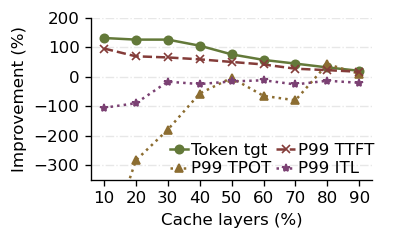

mean_output_tokens_imps: 80.17976162130036, mean_reqs_imps: 77.68286895803675, mean_mean_tpot_imps: -71.72343750950236, mean_p99_tpot_imps: -135.9632521996475, mean_mean_ttft_imps: 55.1179321943468, mean_p99_ttft_imps: 50.07250588928225, mean_mean_itl_imps: -28.25800336885174, mean_p99_itl_imps: -36.05201049078558
mean_output_tokens_imps: [80.17976162130036]


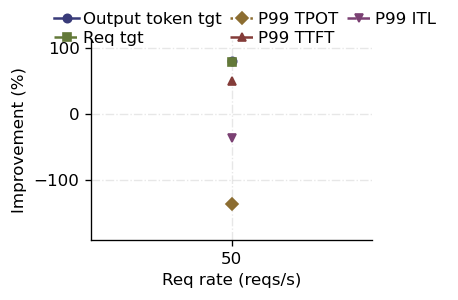

mean_output_tokens_imps: 80.17976162130036, mean_reqs_imps: 77.68286895803675, mean_mean_tpot_imps: -71.72343750950236, mean_p99_tpot_imps: -135.9632521996475, mean_mean_ttft_imps: 55.1179321943468, mean_p99_ttft_imps: 50.07250588928225, mean_mean_itl_imps: -28.25800336885174, mean_p99_itl_imps: -36.05201049078558
mean_p99_tpot_imps: [-135.9632521996475]
baseline_policy---------------------->: recompute
mean_output_tokens_imps: [[142.9320654582232, 137.176579760918, 137.1870063654421, 115.53616207114075, 84.64995281961455, 64.92281706001035, 51.67060270987454, 38.12644343306382, 26.11499502129635]]


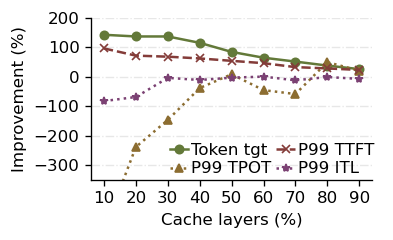

mean_output_tokens_imps: 88.70184718884265, mean_reqs_imps: 85.72845804988661, mean_mean_tpot_imps: -65.745110469348, mean_p99_tpot_imps: -108.09820197357918, mean_mean_ttft_imps: 57.20893675107551, mean_p99_ttft_imps: 53.8376361651737, mean_mean_itl_imps: -23.556983881611657, mean_p99_itl_imps: -20.93359161266398
mean_output_tokens_imps: [88.70184718884265]


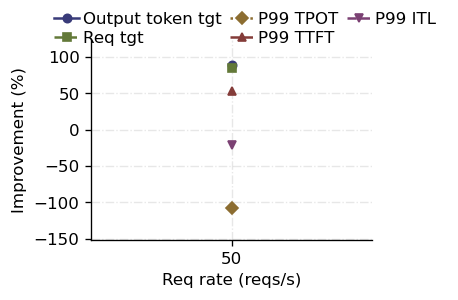

mean_output_tokens_imps: 88.70184718884265, mean_reqs_imps: 85.72845804988661, mean_mean_tpot_imps: -65.745110469348, mean_p99_tpot_imps: -108.09820197357918, mean_mean_ttft_imps: 57.20893675107551, mean_p99_ttft_imps: 53.8376361651737, mean_mean_itl_imps: -23.556983881611657, mean_p99_itl_imps: -20.93359161266398
mean_p99_tpot_imps: [-108.09820197357918]
baseline_policy---------------------->: full_mem
mean_output_tokens_imps: [[17.25370589006952, 22.5053565962657, 20.350693077965815, 6.013599195417376, 12.7694695876514, 12.746512746512737, 1.8682495955223262, -1.332589968953599, 5.6222397131488115]]


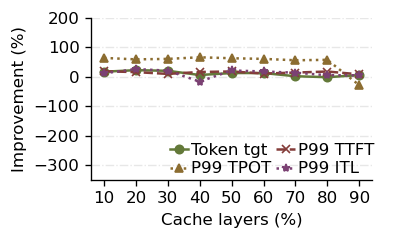

mean_output_tokens_imps: 10.866359603733343, mean_reqs_imps: 8.912655971479495, mean_mean_tpot_imps: 20.828362682430313, mean_p99_tpot_imps: 51.11382598107025, mean_mean_ttft_imps: -1.690151043026959, mean_p99_ttft_imps: 14.516835091458127, mean_mean_itl_imps: 6.01730418943534, mean_p99_itl_imps: 11.810776454717622
mean_output_tokens_imps: [10.866359603733343]


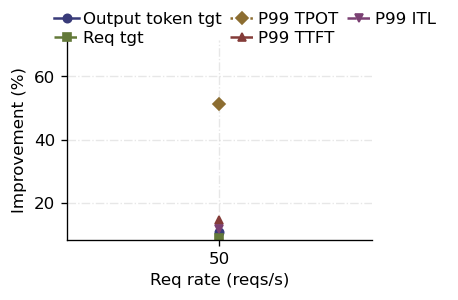

mean_output_tokens_imps: 10.866359603733343, mean_reqs_imps: 8.912655971479495, mean_mean_tpot_imps: 20.828362682430313, mean_p99_tpot_imps: 51.11382598107025, mean_mean_ttft_imps: -1.690151043026959, mean_p99_ttft_imps: 14.516835091458127, mean_mean_itl_imps: 6.01730418943534, mean_p99_itl_imps: 11.810776454717622
mean_p99_tpot_imps: [51.11382598107025]


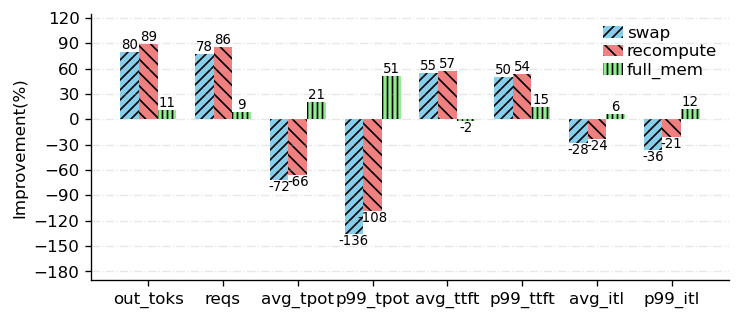

In [210]:
model_name = 'meta-llama/Llama-2-13b-hf'
gpu_utilization = 0.4
plot_all_figs(model_name, gpu_utilization)